# Training ORIGAMI with Continuous Numeric Values

This notebook demonstrates how to train an ORIGAMI model using continuous numeric values with the `OrigamiPipeline` API.

The continuous head uses a Mixture of Gaussians (MoG) output to model numeric values, allowing the model to learn rich distributions over continuous fields rather than discretizing them into bins.

**Key features demonstrated:**
- Using `OrigamiPipeline` for end-to-end training and inference
- `numeric_mode="scale"` for automatic preprocessing of high-cardinality numerics
- Automatic inverse transformation of predictions back to original scale

## 1. Create Dataset

Choose from three synthetic datasets with two numeric fields `a` and `b`:
- **2D Gaussian**: Correlated bivariate normal (unimodal)
- **Two Moons**: Two crescent shapes (bimodal)
- **Spiral**: Swiss roll projected to 2D (multimodal - default)

In [5]:
import random

import numpy as np
import torch
from sklearn.datasets import make_swiss_roll

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_DOCS = 10000

# === Option 1: 2D Gaussian (correlated) ===
# mean = [4, -2]
# cov = [[1.0, 0.7], [0.7, 0.5]]
# samples = np.random.multivariate_normal(mean, cov, NUM_DOCS)
# docs = [{"a": float(x), "b": float(y)} for x, y in samples]

# === Option 2: Two Moons (two crescents) ===
# X, _ = make_moons(n_samples=NUM_DOCS, noise=0.1, random_state=SEED)
# docs = [{"a": float(x), "b": float(y)} for x, y in X]

# === Option 3: Spiral (Swiss Roll projected to 2D) ===
X, _ = make_swiss_roll(n_samples=NUM_DOCS, noise=0.5, random_state=SEED)
docs = [{"a": float(x), "b": float(y)} for x, y in zip(X[:, 0], X[:, 2], strict=True)]

print(f"Created {len(docs)} documents")
print(f"Sample docs: {docs[:3]}")

Created 10000 documents
Sample docs: [{'a': -3.523076247501524, 'b': 7.9134248300437715}, {'a': 6.418099388712395, 'b': 12.300993855187386}, {'a': 7.35895124780617, 'b': -9.205029997199858}]


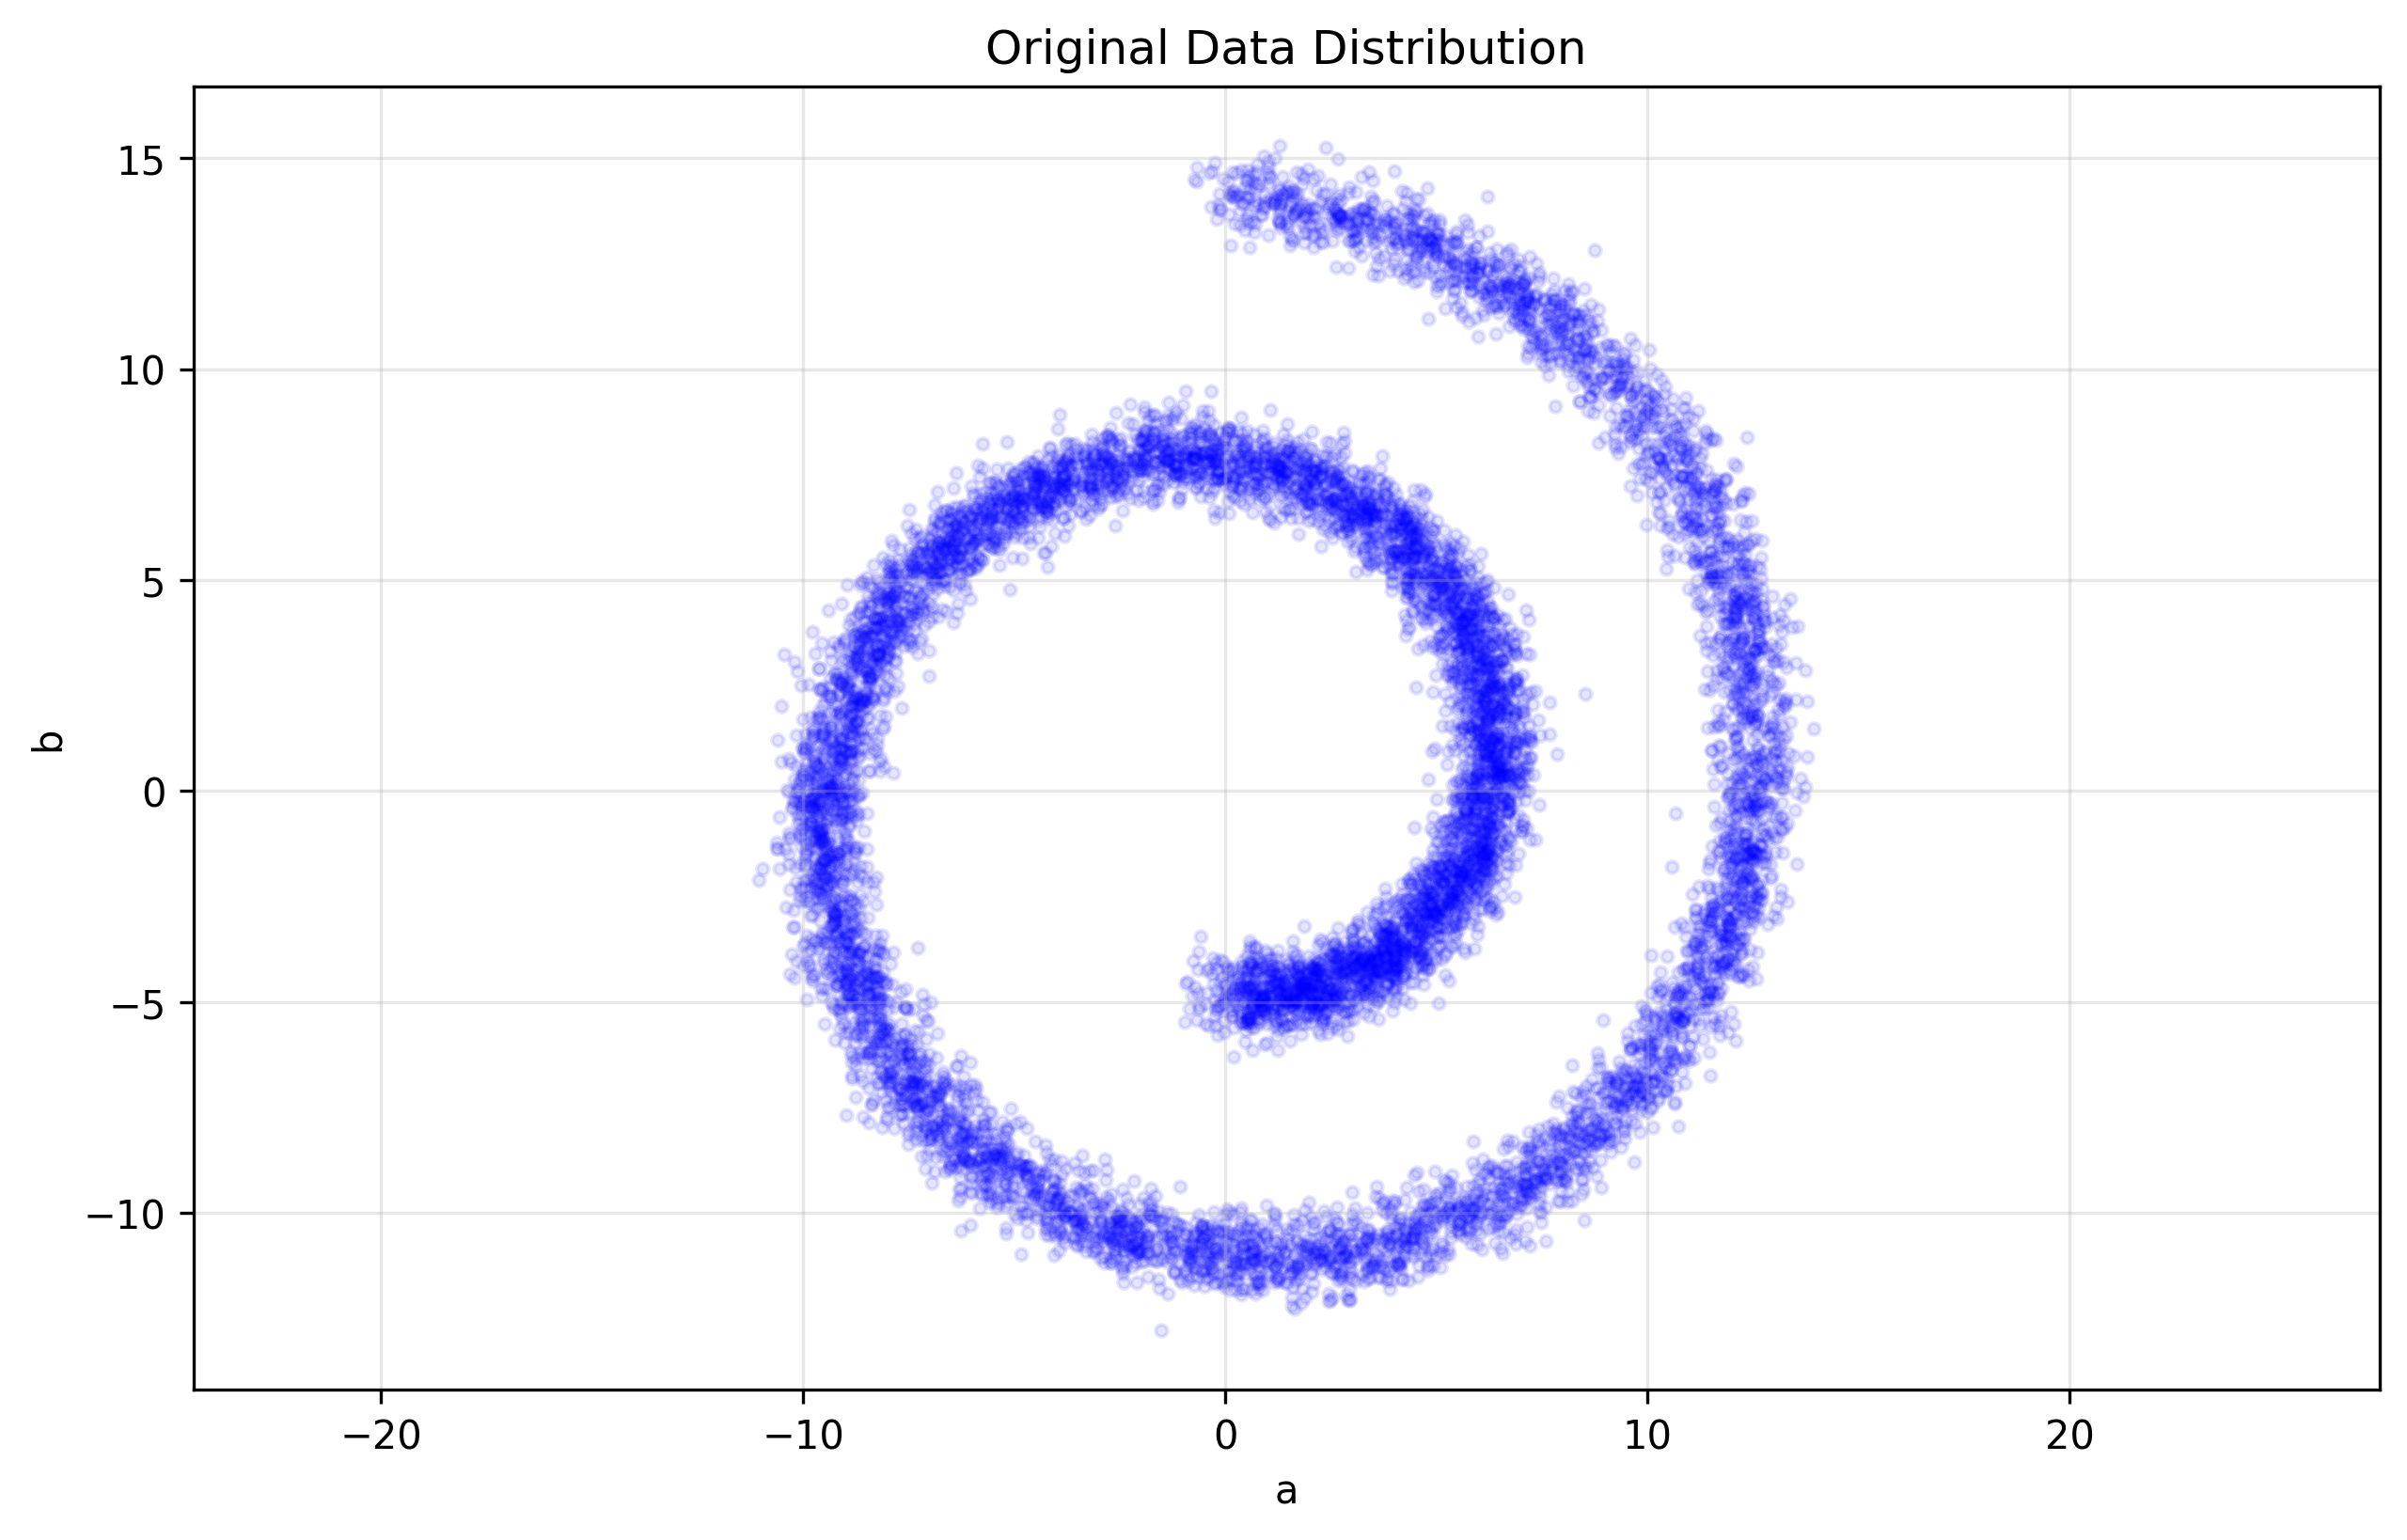

In [6]:
# Plot the data in a 2D scatter plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
plt.scatter([d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.1, color="blue")
plt.title("Original Data Distribution")
plt.xlabel("a")
plt.ylabel("b")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Configure and Train with OrigamiPipeline

The `OrigamiPipeline` handles all the complexity:
- **Preprocessing**: Automatically identifies high-cardinality numeric fields and applies NumericScaler
- **Tokenization**: Fits the tokenizer on the preprocessed data
- **Model creation**: Creates the model with continuous head enabled
- **Training**: Trains with the specified configuration

With `numeric_mode="scale"`, fields with more than `cat_threshold` unique values are normalized using StandardScaler and the model uses a Mixture of Gaussians output head for predictions.

In [7]:
from origami import DataConfig, ModelConfig, OrigamiConfig, OrigamiPipeline, TrainingConfig

# Configure pipeline with continuous numeric handling
config = OrigamiConfig(
    model=ModelConfig(
        d_model=64,
        n_heads=4,
        n_layers=4,
        d_ff=256,
        dropout=0.0,
        num_mixture_components=5,
    ),
    training=TrainingConfig(
        batch_size=64,
        learning_rate=1e-3,
        warmup_steps=100,
        num_epochs=30,
        shuffle_keys=True,  # Key order doesn't matter for this simple dataset
    ),
    data=DataConfig(
        numeric_mode="scale",  # "scale" enables continuous head with MoG
        cat_threshold=20,  # Fields with >20 unique values get scaled
    ),
)

# Create pipeline
pipeline = OrigamiPipeline(config)
print(f"Pipeline config: d_model={config.model.d_model}, numeric_mode={config.data.numeric_mode}")

Pipeline config: d_model=64, numeric_mode=scale


## 3. Train the Pipeline

A single `fit()` call handles everything: preprocessing, tokenization, model creation, and training.

In [ ]:
# Split data
train_size = int(0.9 * len(docs))
train_docs = docs[:train_size]
eval_docs = docs[train_size:]

print(f"Train size: {len(train_docs)}")
print(f"Eval size: {len(eval_docs)}")

# Fit the pipeline (handles preprocessing, tokenization, model creation, training)
pipeline.fit(train_docs, eval_data=eval_docs, verbose=True)

print(f"\nModel parameters: {pipeline._model.get_num_parameters():,}")
print(f"Continuous head enabled: {pipeline._model.continuous_head is not None}")

Train size: 9000
Eval size: 1000
Infer schema: False
Scaled fields (2):
  - a: mean=1.909, std=6.62
  - b: mean=0.1984, std=6.928
Vocabulary size: 12
Model parameters: 219,035
Training device: mps
Training on mps
Train samples: 9000
Eval samples: 1000
Batch size: 64
Epochs: 30
Total steps: 4200



Epoch 1:   0%|          | 0/140 [00:00<?, ?batch/s]

Epoch 1/30 - loss: 0.6858 - tokens/sec: 17461
Eval: val_loss: 0.5277


Epoch 2:   0%|          | 0/140 [00:00<?, ?batch/s]

Epoch 2/30 - loss: 0.4880 - tokens/sec: 18206
Eval: val_loss: 0.4659


...

Epoch 24:   0%|          | 0/140 [00:00<?, ?batch/s]

Epoch 24/30 - loss: 0.3192 - tokens/sec: 16765
Eval: val_loss: 0.3159


Epoch 25:   0%|          | 0/140 [00:00<?, ?batch/s]

Epoch 25/30 - loss: 0.3160 - tokens/sec: 17108
Eval: val_loss: 0.3050


Epoch 26:   0%|          | 0/140 [00:00<?, ?batch/s]

In [ ]:
# save pipeline
# pipeline.save("origami_2d_pipeline.pt")

# optionally load pipeline
# pipeline = OrigamiPipeline.load("origami_2d_pipeline.pt")

## 4. Inspect the Preprocessor

The pipeline automatically created a NumericScaler and fitted it on the training data. We can inspect what fields were scaled.

In [ ]:
# The pipeline's preprocessor is a NumericScaler
print("Preprocessor summary:")
print(pipeline._preprocessor.summary())

## 5. Generate Samples from the Model

The `generate()` method samples complete JSON objects from the model. When the model generates a `NUM` token, it samples from the learned Mixture of Gaussians distribution.

**Important:** The pipeline automatically inverse-transforms generated values back to the original scale.

In [ ]:
# Generate samples - values are automatically inverse-transformed to original scale
n_samples = 1000
generated_samples = pipeline.generate(num_samples=n_samples, temperature=0.8, top_p=0.95)

print(f"Generated {len(generated_samples)} samples")
print(f"Sample generated docs: {generated_samples[:3]}")

# Extract values for plotting - only keep samples where both a and b are numeric
generated_a = []
generated_b = []
for s in generated_samples:
    if isinstance(s, dict) and "a" in s and "b" in s:
        a_val, b_val = s["a"], s["b"]
        if isinstance(a_val, (int, float)) and isinstance(b_val, (int, float)):
            generated_a.append(float(a_val))
            generated_b.append(float(b_val))

print(f"\nSuccessfully extracted {len(generated_a)} / {n_samples} valid samples")
if len(generated_a) < n_samples:
    print(f"({n_samples - len(generated_a)} samples had non-numeric or missing values)")

In [ ]:
# Plot original data vs generated samples
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Original data
plt.scatter(
    [d["a"] for d in docs],
    [d["b"] for d in docs],
    marker=".",
    alpha=0.1,
    color="blue",
    label="Original Data",
)

# Generated samples
plt.scatter(
    generated_a, generated_b, marker=".", alpha=0.5, color="orange", label="Generated Samples"
)

plt.title("Original Data vs Generated Samples")
plt.xlabel("a")
plt.ylabel("b")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Visualize Marginal Distributions

Let's compare the marginal distributions of the original data vs generated samples.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Field 'a' distribution
axes[0].hist(
    [d["a"] for d in docs], bins=50, alpha=0.5, density=True, label="Original", color="blue"
)
axes[0].hist(generated_a, bins=50, alpha=0.5, density=True, label="Generated", color="orange")
axes[0].set_title("Distribution of field 'a'")
axes[0].set_xlabel("a")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Field 'b' distribution
axes[1].hist(
    [d["b"] for d in docs], bins=50, alpha=0.5, density=True, label="Original", color="blue"
)
axes[1].hist(generated_b, bins=50, alpha=0.5, density=True, label="Generated", color="orange")
axes[1].set_title("Distribution of field 'b'")
axes[1].set_xlabel("b")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.set_dpi(300)
plt.tight_layout()
plt.show()

## 7. Visualizing Conditional Distributions p(b|a)

For complex distributions like spirals, there's no single "correct" prediction for `b` given `a` - the spiral crosses each x-coordinate multiple times, creating a **multimodal conditional distribution**.

Instead of measuring prediction accuracy, we visualize how well the model's Mixture of Gaussians captures this multimodality:
- Pick an `a` value where the spiral has multiple crossings
- Show the actual distribution of `b` values at that `a` (histogram)
- Overlay the model's predicted MoG distribution
- See how the mixture components align with the data modes

In [ ]:
from origami.preprocessing import move_target_last
from origami.tokenizer.vocabulary import KeyToken
from origami.training import OrigamiDataCollator

# Access internal components
model = pipeline._model
tokenizer = pipeline._tokenizer
scaler = pipeline._preprocessor
collator = OrigamiDataCollator(tokenizer)


def get_mog_params(a_value: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Get MoG parameters (weights, means, stds) for predicting b given a."""
    # Create input document
    doc = {"a": a_value, "b": None}
    scaled_doc = scaler.transform([doc])[0]
    reordered = move_target_last(scaled_doc, "b")

    # Tokenize and prepare batch
    instance = tokenizer.tokenize(reordered)
    batch = collator([instance])

    # Forward pass
    model.eval()
    with torch.no_grad():
        output = model(
            batch.input_ids,
            batch.path_types,
            batch.path_ids,
            batch.path_lengths,
            batch.attention_mask,
            numeric_values=batch.numeric_values,
        )

    # Get params at position predicting 'b' value
    weights, means, log_vars = output.continuous_params
    b_key_id = tokenizer.vocab.encode(KeyToken("b"))
    b_pos = (batch.input_ids[0] == b_key_id).nonzero(as_tuple=True)[0][-1].item()

    w = weights[0, b_pos].numpy()
    m = means[0, b_pos].numpy()
    s = np.exp(0.5 * log_vars[0, b_pos].numpy())

    # Inverse transform to original scale
    stats = scaler.get_scaler_stats("b")
    m_orig = m * stats["std"] + stats["mean"]
    s_orig = s * stats["std"]

    return w, m_orig, s_orig


def mog_pdf(x: np.ndarray, weights: np.ndarray, means: np.ndarray, stds: np.ndarray) -> np.ndarray:
    """Compute Mixture of Gaussians PDF."""
    pdf = np.zeros_like(x)
    for w, m, s in zip(weights, means, stds, strict=True):
        pdf += w * np.exp(-0.5 * ((x - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
    return pdf


print("Helper functions defined.")

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Precompute data bounds
all_a = np.array([d["a"] for d in docs])
all_b = np.array([d["b"] for d in docs])
a_min, a_max = all_a.min(), all_a.max()
b_min, b_max = all_b.min(), all_b.max()


def plot_conditional(a_value: float, tolerance: float = 1.0):
    """Plot conditional distribution p(b|a) at given a value."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Left plot: Scatter with vertical slice highlighted
    axes[0].scatter(all_a, all_b, alpha=0.1, s=10, c="blue", label="Data")
    axes[0].axvline(a_value, color="red", linestyle="-", linewidth=2, label=f"a = {a_value:.1f}")
    axes[0].axvline(a_value - tolerance, color="red", linestyle="--", alpha=0.5, linewidth=1)
    axes[0].axvline(a_value + tolerance, color="red", linestyle="--", alpha=0.5, linewidth=1)
    axes[0].axvspan(a_value - tolerance, a_value + tolerance, alpha=0.1, color="red")

    # Highlight points in slice
    mask = np.abs(all_a - a_value) < tolerance
    axes[0].scatter(
        all_a[mask],
        all_b[mask],
        alpha=0.8,
        s=20,
        c="red",
        label=f"Points in slice (n={mask.sum()})",
    )

    axes[0].set_xlabel("a")
    axes[0].set_ylabel("b")
    axes[0].set_title("Data with vertical slice")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(a_min - 2, a_max + 2)
    axes[0].set_ylim(b_min - 2, b_max + 2)

    # Right plot: Histogram of b values (horizontal) aligned with y-axis
    b_in_slice = all_b[mask]

    if len(b_in_slice) > 0:
        # Get model's MoG prediction
        weights, means, stds = get_mog_params(a_value)

        # Plot range for b (now on y-axis)
        b_range = np.linspace(b_min - 2, b_max + 2, 300)

        # Horizontal histogram of actual data
        axes[1].hist(
            b_in_slice,
            bins=30,
            density=True,
            alpha=0.5,
            color="blue",
            label="Actual p(b|a)",
            orientation="horizontal",
        )

        # Plot individual mixture components (swap x and y)
        colors = plt.cm.Set2(np.linspace(0, 1, len(weights)))
        for i, (w, m, s, c) in enumerate(zip(weights, means, stds, colors, strict=True)):
            if w > 0.01:  # Only show significant components
                component_pdf = (
                    w * np.exp(-0.5 * ((b_range - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
                )
                axes[1].plot(
                    component_pdf,
                    b_range,
                    "--",
                    color=c,
                    alpha=0.7,
                    label=f"Component {i + 1} (w={w:.2f})",
                )
                axes[1].axhline(m, color=c, linestyle=":", alpha=0.5)

        # Plot mixture PDF (swap x and y)
        mixture_pdf = mog_pdf(b_range, weights, means, stds)
        axes[1].plot(mixture_pdf, b_range, "r-", linewidth=2.5, label="MoG prediction")

        axes[1].set_xlabel("Density")
        axes[1].set_title(f"p(b | a={a_value:.1f})")
        axes[1].legend(loc="upper right", fontsize=8)
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(
            0.5,
            0.5,
            "No data points in slice",
            ha="center",
            va="center",
            transform=axes[1].transAxes,
        )
        axes[1].set_title(f"p(b | a={a_value:.1f})")

    plt.tight_layout()
    plt.show()


# Create interactive widget
a_slider = widgets.FloatSlider(
    value=5.0,
    min=float(a_min),
    max=float(a_max),
    step=0.5,
    description="a value:",
    continuous_update=False,
)
tolerance_slider = widgets.FloatSlider(
    value=1.0, min=0.3, max=3.0, step=0.1, description="Tolerance:", continuous_update=False
)

interactive_plot = widgets.interactive(
    plot_conditional, a_value=a_slider, tolerance=tolerance_slider
)
display(interactive_plot)

## 8. Static View: Multiple Slices

If the interactive widget doesn't work in your environment, here's a static view showing the conditional distribution at several `a` values.

In [ ]:
# Static multi-panel view at different a values
a_values = [-8, -4, 0, 4, 8]
tolerance = 1.0

fig, axes = plt.subplots(2, len(a_values), figsize=(18, 8), gridspec_kw={"height_ratios": [2, 2]})

for col, a_val in enumerate(a_values):
    # Top row: scatter with slice + aligned distribution
    ax_main = axes[0, col]
    ax_main.scatter(all_a, all_b, alpha=0.1, s=5, c="blue")
    ax_main.axvline(a_val, color="red", linewidth=2)
    ax_main.axvspan(a_val - tolerance, a_val + tolerance, alpha=0.2, color="red")

    mask = np.abs(all_a - a_val) < tolerance
    ax_main.scatter(all_a[mask], all_b[mask], alpha=0.8, s=15, c="red")

    # Overlay the MoG distribution as a horizontal density plot at the slice position
    if mask.sum() > 5:
        weights, means, stds = get_mog_params(float(a_val))
        b_range = np.linspace(b_min - 2, b_max + 2, 200)
        mixture_pdf = mog_pdf(b_range, weights, means, stds)

        # Scale PDF to fit nicely in the plot (adjust width)
        pdf_scaled = mixture_pdf / mixture_pdf.max() * 4  # Scale to ~4 units wide
        ax_main.plot(a_val + pdf_scaled, b_range, "orange", linewidth=2, alpha=0.8)
        ax_main.fill_betweenx(b_range, a_val, a_val + pdf_scaled, alpha=0.3, color="orange")

        # Mark component means
        for w, m in zip(weights, means, strict=True):
            if w > 0.05:
                ax_main.plot(
                    [a_val, a_val + 2], [m, m], "orange", linestyle="--", alpha=0.7, linewidth=1
                )

    ax_main.set_xlim(a_min - 2, a_max + 2)
    ax_main.set_ylim(b_min - 2, b_max + 2)
    ax_main.set_title(f"a = {a_val}")
    ax_main.set_xlabel("a")
    if col == 0:
        ax_main.set_ylabel("b")
    ax_main.grid(True, alpha=0.3)

    # Bottom row: horizontal histogram for comparison
    ax_hist = axes[1, col]
    b_in_slice = all_b[mask]

    if len(b_in_slice) > 5:
        ax_hist.hist(
            b_in_slice, bins=20, density=True, alpha=0.5, color="blue", orientation="horizontal"
        )

        weights, means, stds = get_mog_params(float(a_val))
        b_range = np.linspace(b_min - 2, b_max + 2, 200)
        mixture_pdf = mog_pdf(b_range, weights, means, stds)
        ax_hist.plot(mixture_pdf, b_range, "r-", linewidth=2)

        ax_hist.set_xlabel("Density")
        ax_hist.set_ylim(b_min - 2, b_max + 2)
    else:
        ax_hist.text(0.5, 0.5, "Few points", ha="center", va="center", transform=ax_hist.transAxes)

    ax_hist.grid(True, alpha=0.3)

fig.set_dpi(300)

plt.suptitle("Conditional distributions p(b|a) at different slices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated how to use `OrigamiPipeline` with continuous numeric values on a **spiral dataset**:

1. **Complex density modeling**: The Mixture of Gaussians (MoG) head can capture multimodal conditional distributions where a single `a` value maps to multiple possible `b` values

2. **Generation quality**: Generated samples follow the spiral structure of the training data

3. **Conditional distributions**: The model learns proper p(b|a) distributions - at each slice, the mixture components align with where the spiral actually crosses

**Key insight**: Unlike simple regression where we predict a single value, the MoG head models the full conditional distribution. This is essential for complex structures like spirals where the mapping is inherently multimodal.

**Try experimenting with:**
- Different `num_mixture_components` (more components for more complex distributions)
- The two moons dataset (Option 2) for a simpler bimodal example
- The 2D Gaussian (Option 1) to see how the model handles unimodal distributions